# Run KernelSHAP

In [1]:
import xarray as xr
import matplotlib.pyplot as plt

from pkg.shap.kernel_shap import run_kernel_shap

In [2]:
features = [
    "2m_temperature",
    ("10m_u_component_of_wind", "10m_v_component_of_wind"),
    "total_precipitation_6hr",
    "mean_sea_level_pressure",
    "temperature",
    ("u_component_of_wind", "v_component_of_wind"),
    "geopotential",
    "vertical_velocity",
    "specific_humidity",
]

input_path="../data/prediction_zeynep_22/input_data/graphcast_ready_input_zeynep_22_graphcast_small.nc"
climate_path="../data/data_for_climatology/era5_1979-2015_0218_climatology.nc"

input_ds = xr.open_dataset(input_path)
climatology_ds = xr.open_dataset(climate_path)

In [ ]:
shap_df = run_kernel_shap(
    features=features,
    input_ds=input_ds,
    climatology_ds=climatology_ds,
    shap_folder="../data/shap/variables_500samples",
    nsamples=500
)

print(shap_df)


In [1]:
print(shap_df)

NameError: name 'shap_df' is not defined

In [ ]:
# Save to CSV
out_csv = "../data/shap/shap_variables_500_samples.csv"
shap_df.to_csv(out_csv, index=False)

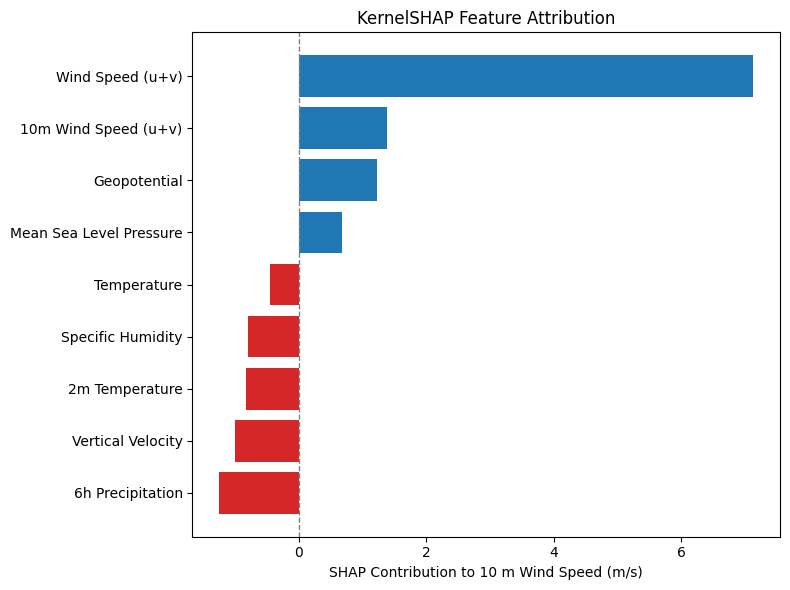

In [ ]:
# 1) Define your pretty names
pretty_names = {
    "2m_temperature":    "2m Temperature",
    "10m_u_component_of_wind+10m_v_component_of_wind": "10m Wind Speed (u+v)",
    "total_precipitation_6hr": "6h Precipitation",
    "mean_sea_level_pressure": "Mean Sea Level Pressure",
    "temperature": "Temperature",
    "u_component_of_wind+v_component_of_wind": "Wind Speed (u+v)",
    "geopotential": "Geopotential",
    "vertical_velocity": "Vertical Velocity",
    "specific_humidity": "Specific Humidity",
}

# 2) Sort and map labels
plot_df = shap_df.sort_values("shap_value").copy()
plot_df["label"] = plot_df["feature"].map(pretty_names).fillna(plot_df["feature"])

# 3) Plot using the new label column
plt.figure(figsize=(8, 6))
plt.barh(plot_df["label"], plot_df["shap_value"], color=[
    "#d62728" if v < 0 else "#1f77b4" for v in plot_df["shap_value"]
])
plt.xlabel("SHAP Contribution to 10 m Wind Speed (m/s)")
plt.title("KernelSHAP Feature Attribution")
plt.axvline(0, color="gray", linestyle="--", linewidth=1)
plt.tight_layout()
plt.show()


In [13]:
from pkg.mask.generate_mask import compute_wind_speed

# Compute 10 m wind speed for each dataset
input_ws = compute_wind_speed(
    input_ds,
    u_name="10m_u_component_of_wind",
    v_name="10m_v_component_of_wind",
    new_name="10m_wind_speed"
)["10m_wind_speed"]

clim_ws = compute_wind_speed(
    climatology_ds,
    u_name="10m_u_component_of_wind",
    v_name="10m_v_component_of_wind",
    new_name="10m_wind_speed"
)["10m_wind_speed"]

# Select the last time step
input_last = input_ws.isel(time=-1)
clim_last  = clim_ws.isel(time=-1)

# Drop batch dim if present
if "batch" in input_last.dims:
    input_last = input_last.isel(batch=0)
if "batch" in clim_last.dims:
    clim_last = clim_last.isel(batch=0)

# Subset North Germany: 53–55 °N, 8–10 °E
lat_cond = (input_last.lat >= 53.0) & (input_last.lat <= 55.0)
lon_cond = (input_last.lon >= 8.0)  & (input_last.lon <= 10.0)

input_reg = input_last.where(lat_cond & lon_cond, drop=True)
clim_reg  = clim_last.where(lat_cond & lon_cond, drop=True)

# Compute regional mean
mean_input_ws = input_reg.mean(dim=["lat", "lon"]).item()
mean_clim_ws  = clim_reg.mean(dim=["lat", "lon"]).item()

print(f"North Germany mean 10 m wind at last time (input)      : {mean_input_ws:.3f} m/s")
print(f"North Germany mean 10 m wind at last time (climatology): {mean_clim_ws:.3f} m/s")



North Germany mean 10 m wind at last time (input)      : 14.723 m/s
North Germany mean 10 m wind at last time (climatology): 1.540 m/s
